# Modul 3: Optimizer dan Strategi Pelatihan

**Nama:** Fadil Alfarizzi  
**NIM:** 123450048  
**Kelas:** RC  
**Tanggal:** 2026-09-29  

Simpan berkas ini sebagai `M03_NIM.ipynb` sebelum mulai mengerjakan.

## Petunjuk

Notebook ini memiliki tiga jenis bagian. Tanda di akhir judul menunjukkan jenisnya.

| Tanda | Bagian | Yang Anda lakukan |
|:---|:---|:---|
| **Terbimbing** | Pre-lab, B–F | Jawaban lengkap Prosedur Praktikum Terbimbing sudah tersedia, termasuk run tanpa scheduler, `StepLR`, batch 32, dan batch 512 pada bagian F. Jalankan, baca kodenya, lalu cocokkan keluarannya dengan tab **Materi** modul. |
| **Latihan Mandiri di Lab** | Latihan | Dikerjakan sendiri di laboratorium setelah bagian terbimbing. |
| **Tugas Individu** | F (lanjutan), G | Run `CosineAnnealingLR` dan batch 128, `metrics.csv` lengkap, serta pertanyaan analisis. Dikerjakan di luar sesi dan dikumpulkan lewat Tugas. |

1. Isi identitas di atas dan `NIM` pada sel pertama. Hanya itu isian pada bagian terbimbing.
2. Siapkan Fashion-MNIST lewat tombol **Siapkan dataset di laptop** di halaman modul. Setelah itu tekan **Restart**, lalu **Run all**. Seluruh sel terbimbing berjalan di kernel Deep Learning (PyTorch CPU) dan berhenti di sel Latihan pertama yang masih berisi `TODO`.
3. Keluaran yang tidak bergantung pada NIM, misalnya jumlah parameter model, harus sama persis dengan naskah. Split, loss, dan akurasi bergantung pada seed NIM Anda, sedangkan runtime bergantung pada perangkat.
4. Protokol tetap: subset 12.000/3.000, model 784 → 128 → 10, batch 128, dan 5 epoch. Pada bagian Latihan dan Tugas, ganti seluruh penanda `TODO`, ubah **hanya** faktor yang sedang diuji, dan panggil fungsi `jalankan()` yang sama untuk setiap run.
5. Pilih model dari validation loss. Data uji sudah dipakai **satu kali** pada bagian E dan tidak dipakai lagi.
6. Catat setiap run ke `metrics.csv`, termasuk run yang gagal. Sebelum mengumpulkan, jalankan **Restart** lalu **Run all** sampai seluruh sel selesai tanpa galat.

In [1]:
import math
import platform
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchvision.datasets import FashionMNIST

# Kernel Workbench menangkap figure di akhir setiap sel; plt.show() dipertahankan
# agar notebook tetap berjalan di Jupyter biasa, tanpa peringatan backend Agg.
warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive')

NIM = '123450048'
assert NIM.isdigit() and len(NIM) >= 4, 'Isi NIM dengan angka sebelum melanjutkan.'
SEED = int(NIM[-4:])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)
environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'torch': torch.__version__,
    'device': str(DEVICE),
    'seed': SEED,
}
environment

{'python': '3.13.14', 'numpy': '2.5.3', 'pandas': '3.0.5', 'torch': '2.14.0+cpu', 'device': 'cpu', 'seed': 48}

## A. Pre-lab · Terbimbing

Contoh jawaban. Bandingkan dengan jawaban Anda sendiri sebelum sesi.

1. **Jumlah update satu epoch bila $n=12\,000$ dan batch $=128$:** $\lceil12000/128\rceil=94$ update (93 batch penuh dan satu batch terakhir berisi 96 contoh). Lima epoch berarti 470 update.
2. **Derau gradien pada mini-batch:** Gradien sebuah mini-batch hanya merupakan estimasi gradien seluruh dataset; komposisi sampel yang berubah membuat arah dan besarnya berfluktuasi. Full-batch memakai semua contoh pada setiap update, sehingga tidak memiliki variasi akibat pemilihan subset—walaupun optimisasi tetap dapat sulit karena bentuk permukaan loss.
3. **Mengapa learning rate yang sama belum tentu adil:** SGD, Momentum, dan Adam mengubah gradien menjadi langkah dengan aturan dan skala efektif berbeda. Aturan yang berbeda membuat learning rate yang sama menghasilkan besar langkah efektif yang tidak setara, sehingga setiap optimizer perlu dituning pada rentangnya sendiri.
4. **Perkiraan kurva bila learning rate dinaikkan sepuluh kali:** Loss mungkin turun lebih cepat pada awalnya, tetapi jika langkah melewati minimum kurva menjadi bergerigi/berosilasi, dapat naik, atau menjadi non-finite. Kapan gejala itu mulai tampak perlu dibaca dari kurva run Anda sendiri.

## B. Data dan protokol · Terbimbing

Ambil subset terstratifikasi dan hitung statistik normalisasi **hanya** dari subset latih.

In [2]:
DATA_ROOT = Path('../../data/raw')
if not DATA_ROOT.exists():
    DATA_ROOT = Path('data/raw')

latih_penuh = FashionMNIST(root=DATA_ROOT, train=True, download=False,
                           transform=transforms.ToTensor())
uji_resmi = FashionMNIST(root=DATA_ROOT, train=False, download=False,
                         transform=transforms.ToTensor())

X_penuh = latih_penuh.data.float().unsqueeze(1) / 255.0
y_penuh = latih_penuh.targets
X_uji = uji_resmi.data.float().unsqueeze(1) / 255.0
y_uji = uji_resmi.targets

semua_indeks = np.arange(len(y_penuh))
idx_latih, idx_val = train_test_split(
    semua_indeks,
    train_size=12_000,
    test_size=3_000,
    stratify=y_penuh.numpy(),
    random_state=SEED,
)

X_latih, y_latih = X_penuh[idx_latih], y_penuh[idx_latih]
X_val, y_val = X_penuh[idx_val], y_penuh[idx_val]

MEAN = X_latih.mean()
STD = X_latih.std()
if not torch.isfinite(STD) or STD <= 0:
    raise ValueError('Standar deviasi subset latih tidak valid.')

def normalkan(tensor):
    return (tensor - MEAN) / STD

ds_latih = TensorDataset(normalkan(X_latih), y_latih)
ds_val = TensorDataset(normalkan(X_val), y_val)
ds_uji = TensorDataset(normalkan(X_uji), y_uji)

print(f'latih {len(ds_latih)}  validasi {len(ds_val)}  uji {len(ds_uji)}')
print(f'mean={MEAN.item():.6f}  std={STD.item():.6f}')
print('distribusi kelas latih:', torch.bincount(y_latih).tolist())

# Pemeriksaan wajib.
assert (len(ds_latih), len(ds_val), len(ds_uji)) == (12_000, 3_000, 10_000)
assert torch.bincount(y_latih).min().item() == 1_200, 'subset harus terstratifikasi'
print('split sesuai protokol')

latih 12000  validasi 3000  uji 10000
mean=0.286274  std=0.353386
distribusi kelas latih: [1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200]
split sesuai protokol


In [3]:
BATCH = 128
EPOCH = 5

def buat_model():
    seed_everything(SEED)
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
    ).to(DEVICE)

def buat_optimizer(nama, params, lr):
    nama = nama.strip().lower()
    if nama == 'sgd':
        return torch.optim.SGD(params, lr=lr)
    if nama == 'momentum':
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if nama == 'adam':
        return torch.optim.Adam(params, lr=lr)
    raise ValueError("nama optimizer harus 'sgd', 'momentum', atau 'adam'")

def loader(ds, batch, acak):
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(ds, batch_size=batch, shuffle=acak,
                      generator=generator if acak else None)

@torch.no_grad()
def evaluasi(model, ds, batch=512):
    model.eval()
    kriteria = nn.CrossEntropyLoss(reduction='sum')
    total_loss, benar = 0.0, 0
    for xb, yb in loader(ds, batch, False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total_loss += kriteria(logits, yb).item()
        benar += (logits.argmax(1) == yb).sum().item()
    return total_loss / len(ds), benar / len(ds)

jumlah_parameter = sum(parameter.numel() for parameter in buat_model().parameters())
print('jumlah parameter:', jumlah_parameter)
assert jumlah_parameter == 101_770, 'arsitektur belum sesuai protokol'

jumlah parameter: 101770


In [4]:
def jalankan(nama_opt, lr, batch=BATCH, epoch=EPOCH, scheduler=None):
    model = buat_model()
    optimizer = buat_optimizer(nama_opt, model.parameters(), lr)
    criterion = nn.CrossEntropyLoss()
    scheduler_name = 'none' if scheduler is None else str(scheduler).lower()
    if scheduler_name == 'none':
        lr_scheduler = None
    elif scheduler_name == 'step':
        lr_scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=2, gamma=0.5,
        )
    elif scheduler_name == 'cosine':
        lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epoch,
        )
    else:
        raise ValueError("scheduler harus None, 'step', atau 'cosine'")

    train_loader = loader(ds_latih, batch, True)
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'val_acc': [], 'learning_rate': [],
    }
    gradient_norms = []
    updates = 0
    status = 'ok'
    start = time.perf_counter()

    for epoch_index in range(1, epoch + 1):
        model.train()
        loss_sum = 0.0
        examples_seen = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            if not torch.isfinite(loss):
                status = f'failed_nonfinite_epoch_{epoch_index}'
                break
            loss.backward()
            squared_norm = sum(
                parameter.grad.detach().norm(2).item() ** 2
                for parameter in model.parameters()
                if parameter.grad is not None
            )
            gradient_norms.append(math.sqrt(squared_norm))
            optimizer.step()
            updates += 1
            loss_sum += loss.item() * len(xb)
            examples_seen += len(xb)

        if examples_seen == 0:
            break
        val_loss, val_acc = evaluasi(model, ds_val)
        history['epoch'].append(epoch_index)
        history['train_loss'].append(loss_sum / examples_seen)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])
        if lr_scheduler is not None:
            lr_scheduler.step()
        if status != 'ok':
            break

    runtime = time.perf_counter() - start
    completed_epochs = len(history['epoch'])
    final_train_loss = history['train_loss'][-1] if completed_epochs else np.nan
    final_val_loss = history['val_loss'][-1] if completed_epochs else np.nan
    final_val_acc = history['val_acc'][-1] if completed_epochs else np.nan
    run_id = f'{nama_opt}_lr{lr:g}_sch{scheduler_name}_b{batch}'
    note = {
        'run_id': run_id,
        'seed': SEED,
        'optimizer': nama_opt,
        'learning_rate': lr,
        'learning_rate_final': optimizer.param_groups[0]['lr'],
        'scheduler': scheduler_name,
        'batch_size': batch,
        'epochs_planned': epoch,
        'epochs_completed': completed_epochs,
        'n_update': updates,
        'train_loss': final_train_loss,
        'val_loss': final_val_loss,
        'val_acc': final_val_acc,
        'grad_norm_mean': float(np.mean(gradient_norms)) if gradient_norms else np.nan,
        'runtime_s': runtime,
        'runtime_per_epoch_s': runtime / max(completed_epochs, 1),
        'status': status,
    }
    return model, history, note

## C. Baseline dan tiga learning rate · Terbimbing

Jalankan SGD pada $\eta \in \{0{,}001;\;0{,}1;\;1{,}0\}$, tampilkan ketiga kurva dalam satu grafik, lalu cocokkan dengan tabel gejala pada modul.

baseline_sgd_lr0.001: val_loss=1.3345, val_acc=0.6600, grad_norm=1.7606
baseline_sgd_lr0.1: val_loss=0.4289, val_acc=0.8430, grad_norm=1.3381
baseline_sgd_lr1: val_loss=1.9346, val_acc=0.2843, grad_norm=1.2540


,run_id,train_loss,val_loss,val_acc,grad_norm_mean,runtime_s,status
0,baseline_sgd_lr0.001,1.3901,1.3345,0.6600,1.7606,2.4356,ok
1,baseline_sgd_lr0.1,0.4013,0.4289,0.8430,1.3381,2.5595,ok
2,baseline_sgd_lr1,1.9250,1.9346,0.2843,1.2540,2.8552,ok


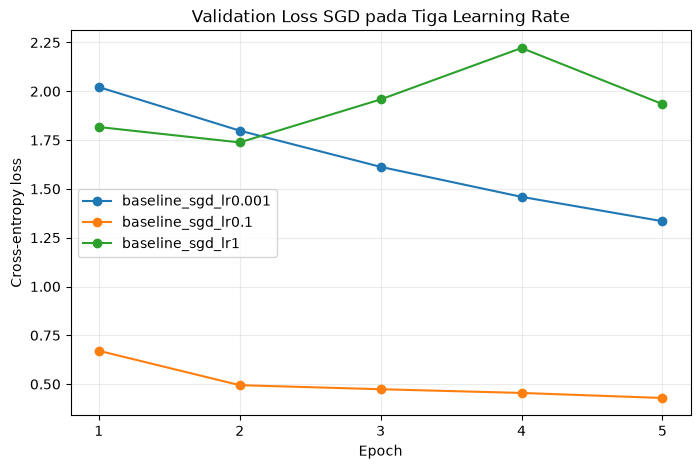

In [5]:
learning_rates_baseline = [0.001, 0.1, 1.0]
hasil_lr = []
riwayat_lr = {}

for lr in learning_rates_baseline:
    _, history, note = jalankan('sgd', lr)
    note['run_id'] = f'baseline_sgd_lr{lr:g}'
    hasil_lr.append(note)
    riwayat_lr[note['run_id']] = history
    print(f"{note['run_id']}: val_loss={note['val_loss']:.4f}, "
          f"val_acc={note['val_acc']:.4f}, grad_norm={note['grad_norm_mean']:.4f}")

df_lr_baseline = pd.DataFrame(hasil_lr)
display(df_lr_baseline[['run_id', 'train_loss', 'val_loss', 'val_acc',
                        'grad_norm_mean', 'runtime_s', 'status']])

fig, ax = plt.subplots(figsize=(8, 5))
for run_id, history in riwayat_lr.items():
    ax.plot(history['epoch'], history['val_loss'], marker='o', label=run_id)
ax.set(title='Validation Loss SGD pada Tiga Learning Rate',
       xlabel='Epoch', ylabel='Cross-entropy loss')
ax.set_xticks(range(1, EPOCH + 1))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

In [6]:
baseline_by_lr = df_lr_baseline.set_index('learning_rate')
small = baseline_by_lr.loc[0.001]
medium = baseline_by_lr.loc[0.1]
large = baseline_by_lr.loc[1.0]

reading = fr"""
**Pembacaan kurva:**

- $\eta=0.001$: turun lambat; validation loss akhir **{small['val_loss']:.4f}**, accuracy **{small['val_acc']:.4f}**, dan `grad_norm_mean` **{small['grad_norm_mean']:.4f}**. Learning rate terlalu kecil untuk anggaran lima epoch.
- $\eta=0.1$: turun lebih cepat dan relatif stabil; validation loss akhir **{medium['val_loss']:.4f}**, accuracy **{medium['val_acc']:.4f}**, dan `grad_norm_mean` **{medium['grad_norm_mean']:.4f}**.
- $\eta=1.0$: langkah sangat agresif; validation loss akhir **{large['val_loss']:.4f}**, accuracy **{large['val_acc']:.4f}**, dan `grad_norm_mean` **{large['grad_norm_mean']:.4f}**. Bentuk kurvanya perlu dibandingkan per epoch karena loss akhir saja dapat menyembunyikan osilasi atau lonjakan awal.
"""
display(Markdown(reading))



**Pembacaan kurva:**

- $\eta=0.001$: turun lambat; validation loss akhir **1.3345**, accuracy **0.6600**, dan `grad_norm_mean` **1.7606**. Learning rate terlalu kecil untuk anggaran lima epoch.
- $\eta=0.1$: turun lebih cepat dan relatif stabil; validation loss akhir **0.4289**, accuracy **0.8430**, dan `grad_norm_mean` **1.3381**.
- $\eta=1.0$: langkah sangat agresif; validation loss akhir **1.9346**, accuracy **0.2843**, dan `grad_norm_mean` **1.2540**. Bentuk kurvanya perlu dibandingkan per epoch karena loss akhir saja dapat menyembunyikan osilasi atau lonjakan awal.


## D. Sembilan run terkendali · Terbimbing

Setiap optimizer diuji pada tiga learning rate-nya sendiri. Model diinisialisasi ulang dari seed yang sama sebelum setiap run.

In [7]:
grid = {
    'sgd': [0.01, 0.1, 0.5],
    'momentum': [0.01, 0.05, 0.1],
    'adam': [1e-4, 1e-3, 1e-2],
}

hasil, riwayat_semua = [], {}
for optimizer_name, learning_rates in grid.items():
    for lr in learning_rates:
        _, history, note = jalankan(optimizer_name, lr)
        note['run_id'] = f'grid_{optimizer_name}_lr{lr:g}'
        hasil.append(note)
        riwayat_semua[note['run_id']] = history
        print(f"{note['run_id']}: val_loss={note['val_loss']:.4f}, "
              f"val_acc={note['val_acc']:.4f}, runtime={note['runtime_s']:.2f}s")

tabel = pd.DataFrame(hasil)
display(tabel[['run_id', 'optimizer', 'learning_rate', 'val_loss', 'val_acc',
               'grad_norm_mean', 'runtime_s', 'status']].sort_values('val_loss'))
assert len(tabel) == 9, 'harus ada sembilan run inti'

grid_sgd_lr0.01: val_loss=0.6000, val_acc=0.7950, runtime=2.47s
grid_sgd_lr0.1: val_loss=0.4289, val_acc=0.8430, runtime=2.33s
grid_sgd_lr0.5: val_loss=0.6107, val_acc=0.7797, runtime=2.43s
grid_momentum_lr0.01: val_loss=0.4298, val_acc=0.8503, runtime=2.53s
grid_momentum_lr0.05: val_loss=0.4029, val_acc=0.8590, runtime=2.44s
grid_momentum_lr0.1: val_loss=0.5243, val_acc=0.8347, runtime=2.41s
grid_adam_lr0.0001: val_loss=0.5325, val_acc=0.8137, runtime=2.91s
grid_adam_lr0.001: val_loss=0.4042, val_acc=0.8573, runtime=2.89s
grid_adam_lr0.01: val_loss=0.4796, val_acc=0.8423, runtime=2.90s


,run_id,optimizer,learning_rate,val_loss,val_acc,grad_norm_mean,runtime_s,status
4,grid_momentum_lr0.05,momentum,0.0500,0.4029,0.8590,1.1780,2.4425,ok
7,grid_adam_lr0.001,adam,0.0010,0.4042,0.8573,1.6380,2.8942,ok
1,grid_sgd_lr0.1,sgd,0.1000,0.4289,0.8430,1.3381,2.3273,ok
3,grid_momentum_lr0.01,momentum,0.0100,0.4298,0.8503,1.4308,2.5336,ok
8,grid_adam_lr0.01,adam,0.0100,0.4796,0.8423,1.6382,2.8975,ok
5,grid_momentum_lr0.1,momentum,0.1000,0.5243,0.8347,1.1428,2.4148,ok
6,grid_adam_lr0.0001,adam,0.0001,0.5325,0.8137,1.3264,2.9112,ok
0,grid_sgd_lr0.01,sgd,0.0100,0.6000,0.7950,1.2716,2.4727,ok
2,grid_sgd_lr0.5,sgd,0.5000,0.6107,0.7797,1.2252,2.4255,ok


## E. Memilih model dan evaluasi akhir · Terbimbing

Pilih learning rate terbaik tiap optimizer dari **validation loss**, bandingkan ketiga pemenang, lalu evaluasi data uji **satu kali** pada satu model final.

Konfigurasi final berdasarkan validation loss: grid_momentum_lr0.05


,run_id,optimizer,learning_rate,val_loss,val_acc,runtime_s,runtime_per_epoch_s
0,grid_momentum_lr0.05,momentum,0.050,0.4029,0.8590,2.4425,0.4885
1,grid_adam_lr0.001,adam,0.001,0.4042,0.8573,2.8942,0.5788
2,grid_sgd_lr0.1,sgd,0.100,0.4289,0.8430,2.3273,0.4655


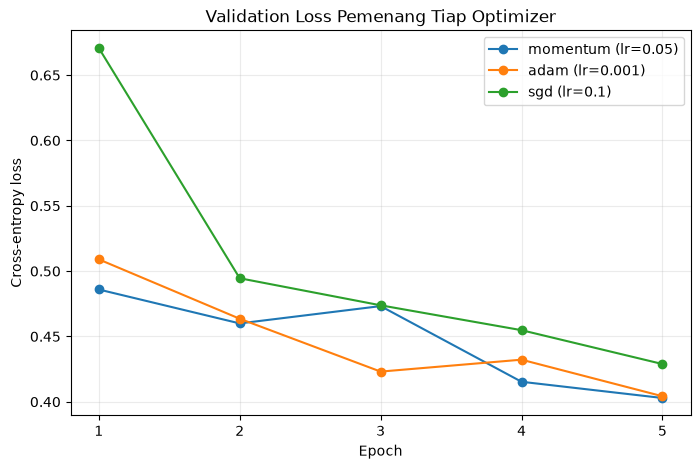

In [8]:
eligible = tabel[(tabel['status'] == 'ok') & np.isfinite(tabel['val_loss'])].copy()
pemenang = (
    eligible.sort_values('val_loss')
    .groupby('optimizer', as_index=False, sort=False)
    .first()
    .sort_values('val_loss')
    .reset_index(drop=True)
)
assert set(pemenang['optimizer']) == set(grid)
display(pemenang[['run_id', 'optimizer', 'learning_rate', 'val_loss', 'val_acc',
                   'runtime_s', 'runtime_per_epoch_s']])

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in pemenang.iterrows():
    history = riwayat_semua[row['run_id']]
    ax.plot(history['epoch'], history['val_loss'], marker='o',
            label=f"{row['optimizer']} (lr={row['learning_rate']:g})")
ax.set(title='Validation Loss Pemenang Tiap Optimizer',
       xlabel='Epoch', ylabel='Cross-entropy loss')
ax.set_xticks(range(1, EPOCH + 1))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

best_overall = pemenang.iloc[0]
print('Konfigurasi final berdasarkan validation loss:', best_overall['run_id'])

,run_id,selection_val_loss,test_loss,test_acc,most_confused_pair,pair_errors
0,final_retrain_momentum_lr0.05,0.4029,0.446,0.8511,T-shirt/top ↔ Shirt,289


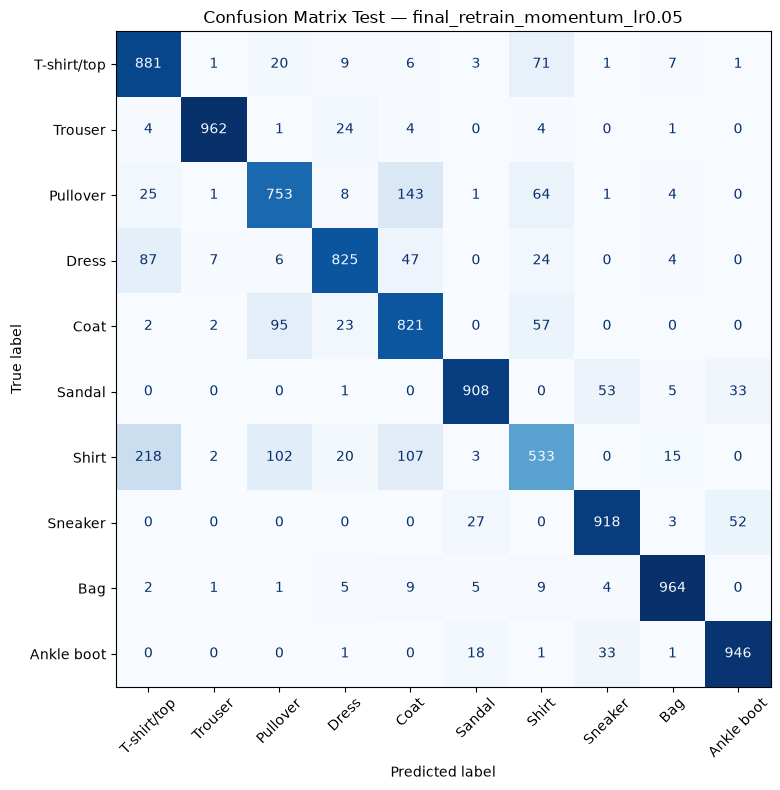

In [9]:
model_final, riwayat_final, catatan_final = jalankan(
    best_overall['optimizer'],
    float(best_overall['learning_rate']),
    batch=BATCH,
    epoch=EPOCH,
    scheduler=None,
)
catatan_final['run_id'] = f"final_retrain_{best_overall['optimizer']}_lr{best_overall['learning_rate']:g}"

@torch.no_grad()
def evaluasi_uji_sekali(model, ds, batch=512):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='sum')
    total_loss = 0.0
    labels_all, predictions_all = [], []
    for xb, yb in loader(ds, batch, False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total_loss += criterion(logits, yb).item()
        labels_all.append(yb.cpu())
        predictions_all.append(logits.argmax(1).cpu())
    labels = torch.cat(labels_all).numpy()
    predictions = torch.cat(predictions_all).numpy()
    return total_loss / len(ds), float((predictions == labels).mean()), labels, predictions

# Satu-satunya iterasi atas ds_uji dalam notebook.
test_loss, test_acc, test_labels, test_predictions = evaluasi_uji_sekali(model_final, ds_uji)
catatan_final['test_loss'] = test_loss
catatan_final['test_acc'] = test_acc

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot',
]
cm = confusion_matrix(test_labels, test_predictions)
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d', xticks_rotation=45,
)
ax.set_title(f"Confusion Matrix Test — {catatan_final['run_id']}")
plt.tight_layout()
plt.show()

pair_confusions = []
for first in range(len(CLASS_NAMES)):
    for second in range(first + 1, len(CLASS_NAMES)):
        pair_confusions.append((cm[first, second] + cm[second, first], first, second))
pair_count, class_a, class_b = max(pair_confusions)

final_summary = pd.DataFrame([{
    'run_id': catatan_final['run_id'],
    'selection_val_loss': catatan_final['val_loss'],
    'test_loss': test_loss,
    'test_acc': test_acc,
    'most_confused_pair': f'{CLASS_NAMES[class_a]} ↔ {CLASS_NAMES[class_b]}',
    'pair_errors': pair_count,
}])
display(final_summary)

**Checkpoint menit ke-95.** Tunjukkan tabel sembilan run dan grafik tiga pemenang kepada asisten sebelum melanjutkan ke bagian F.

## F. Scheduler dan batch size · Terbimbing

Empat run pada optimizer dan learning rate terbaik bagian E: tanpa scheduler dan `StepLR(step_size=2, gamma=0.5)` pada batch 128, lalu batch 32 dan 512 tanpa scheduler. Anggaran tetap lima epoch.

learning rate per epoch dengan StepLR: [0.05, 0.05, 0.025, 0.025, 0.0125]


,run_id,scheduler,batch_size,n_update,val_loss,val_acc,runtime_s,runtime_per_epoch_s,status
0,scheduler_none_momentum_lr0.05,none,128,470,0.4029,0.8590,2.5382,0.5076,ok
1,scheduler_step_momentum_lr0.05,step,128,470,0.3803,0.8677,2.4698,0.4940,ok
2,batch_32_momentum_lr0.05,none,32,1875,0.7179,0.7393,5.7639,1.1528,ok
3,batch_512_momentum_lr0.05,none,512,120,0.4281,0.8503,1.5691,0.3138,ok


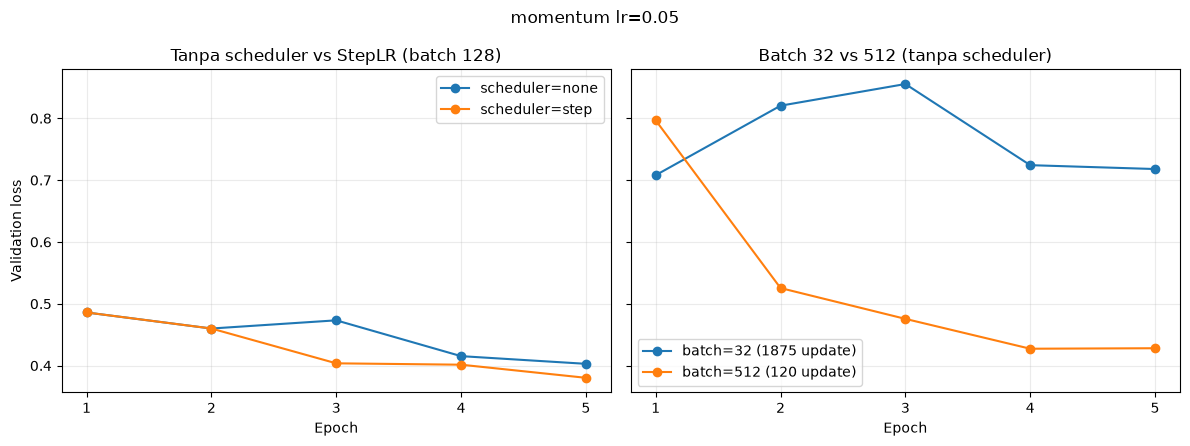

In [10]:
tambahan_terbimbing = []
riwayat_tambahan = {}
best_optimizer = str(best_overall['optimizer'])
best_lr = float(best_overall['learning_rate'])

# Tanpa scheduler vs StepLR pada anggaran epoch yang sama.
for scheduler_name in (None, 'step'):
    _, history, note = jalankan(
        best_optimizer, best_lr, batch=BATCH, epoch=EPOCH,
        scheduler=scheduler_name,
    )
    label = 'none' if scheduler_name is None else scheduler_name
    note['run_id'] = f'scheduler_{label}_{best_optimizer}_lr{best_lr:g}'
    note['experiment_group'] = 'scheduler'
    tambahan_terbimbing.append(note)
    riwayat_tambahan[note['run_id']] = history

# Batch 32 dan 512 tanpa scheduler.
for batch_size in (32, 512):
    _, history, note = jalankan(
        best_optimizer, best_lr, batch=batch_size, epoch=EPOCH, scheduler=None,
    )
    note['run_id'] = f'batch_{batch_size}_{best_optimizer}_lr{best_lr:g}'
    note['experiment_group'] = 'batch_size'
    tambahan_terbimbing.append(note)
    riwayat_tambahan[note['run_id']] = history

df_bagian_f = pd.DataFrame(tambahan_terbimbing)
display(df_bagian_f[['run_id', 'scheduler', 'batch_size', 'n_update',
                     'val_loss', 'val_acc', 'runtime_s', 'runtime_per_epoch_s', 'status']])
print('learning rate per epoch dengan StepLR:',
      riwayat_tambahan[f'scheduler_step_{best_optimizer}_lr{best_lr:g}']['learning_rate'])
assert len(df_bagian_f) == 4
assert (df_bagian_f['status'] == 'ok').all()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, group, title in zip(axes, ['scheduler', 'batch_size'],
                            ['Tanpa scheduler vs StepLR (batch 128)', 'Batch 32 vs 512 (tanpa scheduler)']):
    for note in tambahan_terbimbing:
        if note['experiment_group'] != group:
            continue
        history = riwayat_tambahan[note['run_id']]
        label = (f"scheduler={note['scheduler']}" if group == 'scheduler'
                 else f"batch={note['batch_size']} ({note['n_update']} update)")
        ax.plot(history['epoch'], history['val_loss'], marker='o', label=label)
    ax.set(title=title, xlabel='Epoch')
    ax.set_xticks(range(1, EPOCH + 1))
    ax.grid(alpha=0.25)
    ax.legend()
axes[0].set_ylabel('Validation loss')
fig.suptitle(f'{best_optimizer} lr={best_lr:g}')
plt.tight_layout()
plt.show()

## Latihan Mandiri di Lab

Berdasarkan hasil Bagian E, jelaskan mengapa batch 32 menghasilkan 1.875 update sedangkan batch 512 hanya 120 update untuk anggaran epoch yang sama. Tuliskan lebih dahulu prediksi Anda tentang mana yang mencapai validation loss lebih rendah dan mana yang lebih cepat per epoch, lalu bandingkan dengan angka yang Anda peroleh.

Tuliskan prediksi, hasil, dan perbandingannya di `latihan-03.md`, lalu kumpulkan lewat tugas **Latihan Mandiri di Lab — Modul 03**.

Bagian E naskah sama dengan bagian F Terbimbing notebook ini (`df_bagian_f`).

**Prediksi:** Dengan 12.000 contoh latih, batch 32 membutuhkan $12\,000/32=375$ update per epoch, sedangkan batch 512 hanya $\lceil 12\,000/512\rceil=24$ update per epoch (23 batch penuh dan satu batch berisi 224 contoh). Dalam 5 epoch berarti 1.875 lawan 120 update. Prediksi saya: batch 32 mencapai validation loss lebih rendah karena mendapat update 15 kali lebih banyak, sedangkan batch 512 lebih cepat per epoch karena jumlah iterasinya sedikit dan setiap iterasi memanfaatkan operasi matriks yang lebih besar secara efisien.

In [11]:
# Hitung jumlah update per epoch dan total untuk batch 32 dan 512 dari len(ds_latih) dan EPOCH,
# lalu cocokkan dengan kolom n_update pada df_bagian_f (bagian F).
baris_latihan = []
for batch_size in (32, 512):
    update_per_epoch = math.ceil(len(ds_latih) / batch_size)
    total_update = update_per_epoch * EPOCH
    run = df_bagian_f[(df_bagian_f['experiment_group'] == 'batch_size')
                      & (df_bagian_f['batch_size'] == batch_size)].iloc[0]
    assert run['n_update'] == total_update, 'n_update tidak cocok dengan hitungan'
    baris_latihan.append({
        'batch_size': batch_size,
        'update_per_epoch': update_per_epoch,
        'update_total_hitung': total_update,
        'n_update_run': int(run['n_update']),
        'val_loss': run['val_loss'],
        'val_acc': run['val_acc'],
        'runtime_per_epoch_s': run['runtime_per_epoch_s'],
    })

# Bandingkan val_loss dan runtime_per_epoch_s kedua run dengan prediksi.
df_latihan = pd.DataFrame(baris_latihan)
display(df_latihan)
lebih_rendah = df_latihan.loc[df_latihan['val_loss'].idxmin(), 'batch_size']
lebih_cepat = df_latihan.loc[df_latihan['runtime_per_epoch_s'].idxmin(), 'batch_size']
print(f'validation loss lebih rendah: batch {lebih_rendah}')
print(f'lebih cepat per epoch       : batch {lebih_cepat}')

validation loss lebih rendah: batch 512
lebih cepat per epoch       : batch 512


,batch_size,update_per_epoch,update_total_hitung,n_update_run,val_loss,val_acc,runtime_per_epoch_s
0,32,375,1875,1875,0.7179,0.7393,1.1528
1,512,24,120,120,0.4281,0.8503,0.3138


### Hasil dan perbandingan dengan prediksi

**Jawaban:** Jumlah update pada tabel sama persis dengan hitungan: 1.875 untuk batch 32 dan 120 untuk batch 512. Prediksi kecepatan **benar**: batch 512 hanya sekitar 0,31 detik per epoch, sedangkan batch 32 sekitar 1,15 detik per epoch (hampir empat kali lebih lambat) karena harus menjalankan 375 iterasi kecil. Prediksi validation loss **salah**: batch 512 justru lebih baik (0,4281, akurasi 0,8503) daripada batch 32 (0,7179, akurasi 0,7393). Validation loss batch 32 bahkan naik setelah epoch pertama (0,708 lalu 0,820 dan 0,855). Penyebabnya, learning rate 0,05 dengan momentum 0,9 dipilih pada batch 128. Pada batch 32 gradiennya jauh lebih berderau, sementara besar langkahnya tetap sama, sehingga 1.875 update itu tidak mengendap ke minimum. Batch 512 memiliki gradien yang lebih halus, sehingga 120 update-nya lebih stabil. Jadi jumlah update yang lebih banyak tidak otomatis lebih baik bila learning rate tidak disetel ulang untuk ukuran batch tersebut.

### Hipotesis awal · Tugas Individu

Tuliskan hipotesis yang Anda buat sebelum sesi: optimizer mana yang Anda perkirakan menang, dan atas dasar apa? Bandingkan dengan hasil bagian D dan E.

**Jawaban:** Sebelum sesi saya memperkirakan **Adam dengan $\eta=10^{-3}$** menang pada anggaran 5 epoch, karena langkah adaptif per parameter membuatnya cepat turun tanpa perlu menyetel skala gradien, sementara SGD biasa paling lambat. Hasil bagian D dan E menunjukkan hipotesis ini **hampir tepat, tetapi tidak persis**. Pemenang berdasarkan validation loss adalah SGD+momentum $\eta=0{,}05$ (0,4029), Adam $\eta=10^{-3}$ hanya selisih 0,0013 di belakangnya (0,4042), dan SGD biasa terbaik $\eta=0{,}1$ (0,4289) memang paling lemah. Karena selisih momentum dan Adam sangat kecil pada satu seed, keduanya praktis setara. Bagian hipotesis yang benar adalah bahwa optimizer dengan momentum atau adaptif jauh lebih cepat turun daripada SGD biasa.

## F. Scheduler dan batch size - 15 poin · Tugas Individu

Enam run tambahan, seluruhnya memakai optimizer dan learning rate terbaik Anda. Empat di antaranya (tanpa scheduler, `StepLR`, batch 32, dan batch 512) sudah tersedia dari bagian F Terbimbing di `tambahan_terbimbing`; lengkapi run `CosineAnnealingLR` dan batch 128.

In [12]:
# Tiga run scheduler (None, 'step', 'cosine') pada anggaran epoch yang sama,
# lalu tiga run batch size (32, 128, 512). Laporkan kolom n_update.
# Run None, 'step', batch 32, dan batch 512 sudah tersedia dari bagian F Terbimbing;
# run 'cosine' dan batch 128 ditambahkan lewat jalankan() yang sama.
tambahan = list(tambahan_terbimbing)

_, history, note = jalankan(best_optimizer, best_lr, batch=BATCH, epoch=EPOCH,
                            scheduler='cosine')
note['run_id'] = f'scheduler_cosine_{best_optimizer}_lr{best_lr:g}'
note['experiment_group'] = 'scheduler'
tambahan.append(note)
riwayat_tambahan[note['run_id']] = history
print('learning rate per epoch dengan cosine:', [round(v, 5) for v in history['learning_rate']])

_, history, note = jalankan(best_optimizer, best_lr, batch=128, epoch=EPOCH, scheduler=None)
note['run_id'] = f'batch_128_{best_optimizer}_lr{best_lr:g}'
note['experiment_group'] = 'batch_size'
tambahan.append(note)
riwayat_tambahan[note['run_id']] = history

df_tambahan = pd.DataFrame(tambahan)
df_tambahan = df_tambahan.sort_values(['experiment_group', 'scheduler', 'batch_size']).reset_index(drop=True)
print(df_tambahan[['run_id', 'scheduler', 'batch_size', 'n_update',
                   'val_loss', 'val_acc', 'runtime_s']].to_string(index=False))
assert len(df_tambahan) == 6, 'harus ada enam run tambahan'


learning rate per epoch dengan cosine: [0.05, 0.04523, 0.03273, 0.01727, 0.00477]
                          run_id scheduler  batch_size  n_update  val_loss  val_acc  runtime_s
        batch_32_momentum_lr0.05      none          32      1875    0.7179   0.7393     5.7639
       batch_128_momentum_lr0.05      none         128       470    0.4029   0.8590     2.4359
       batch_512_momentum_lr0.05      none         512       120    0.4281   0.8503     1.5691
scheduler_cosine_momentum_lr0.05    cosine         128       470    0.3744   0.8687     2.6290
  scheduler_none_momentum_lr0.05      none         128       470    0.4029   0.8590     2.5382
  scheduler_step_momentum_lr0.05      step         128       470    0.3803   0.8677     2.4698


In [13]:
# Gabungkan seluruh run ke satu metrics.csv: tiga baseline learning rate,
# sembilan run grid, latih ulang final (dengan metrik uji), dan enam run tambahan.
semua = pd.concat([df_lr_baseline, tabel, pd.DataFrame([catatan_final]), df_tambahan],
                  ignore_index=True)

# Kolom mengikuti template-metrics.csv, ditambah kolom khusus Modul 03.
kelompok = {'baseline': 'baseline learning rate SGD (bagian C)',
            'grid': 'grid optimizer x learning rate (bagian D)',
            'final': 'latih ulang konfigurasi final; data uji dipakai sekali (bagian E)',
            'scheduler': 'eksperimen scheduler (bagian F)',
            'batch': 'eksperimen batch size (bagian F)'}
semua['dataset'] = 'FashionMNIST'
semua['split'] = 'train12000-val3000-test10000'
semua['model'] = 'MLP_784-128-10'
semua['epochs'] = semua['epochs_completed']
semua['val_metric'] = semua['val_acc']
semua['test_metric'] = semua['test_acc'] if 'test_acc' in semua else np.nan
semua['parameters'] = jumlah_parameter
semua['trainable_parameters'] = jumlah_parameter
semua['runtime_seconds'] = semua['runtime_s']
semua['device'] = str(DEVICE)
semua['notes'] = [
    f"{next(v for k, v in kelompok.items() if rid.startswith(k))}; status={st}"
    for rid, st in zip(semua['run_id'], semua['status'])
]
kolom_template = ['run_id', 'seed', 'dataset', 'split', 'model', 'optimizer', 'learning_rate',
                  'batch_size', 'epochs', 'train_loss', 'val_loss', 'val_metric', 'test_metric',
                  'parameters', 'trainable_parameters', 'runtime_seconds', 'device', 'notes']
kolom_tambahan = ['scheduler', 'learning_rate_final', 'n_update', 'val_acc', 'grad_norm_mean',
                  'runtime_per_epoch_s', 'test_loss', 'status']
semua = semua[kolom_template + [k for k in kolom_tambahan if k in semua]]
semua.insert(1, 'module', 'M03')
semua.insert(2, 'student_id', NIM)
semua.to_csv(f'M03_{NIM}_metrics.csv', index=False)
print(f'{len(semua)} baris tersimpan')
display(semua[['run_id', 'optimizer', 'learning_rate', 'scheduler', 'batch_size', 'n_update',
               'val_loss', 'val_metric', 'grad_norm_mean', 'runtime_seconds']])
assert len(semua) >= 15, 'metrics.csv minimal berisi 15 run'


19 baris tersimpan


,run_id,optimizer,learning_rate,scheduler,batch_size,n_update,val_loss,val_metric,grad_norm_mean,runtime_seconds
0,baseline_sgd_lr0.001,sgd,0.0010,none,128,470,1.3345,0.6600,1.7606,2.4356
1,baseline_sgd_lr0.1,sgd,0.1000,none,128,470,0.4289,0.8430,1.3381,2.5595
2,baseline_sgd_lr1,sgd,1.0000,none,128,470,1.9346,0.2843,1.2540,2.8552
3,grid_sgd_lr0.01,sgd,0.0100,none,128,470,0.6000,0.7950,1.2716,2.4727
4,grid_sgd_lr0.1,sgd,0.1000,none,128,470,0.4289,0.8430,1.3381,2.3273
5,grid_sgd_lr0.5,sgd,0.5000,none,128,470,0.6107,0.7797,1.2252,2.4255
6,grid_momentum_lr0.01,momentum,0.0100,none,128,470,0.4298,0.8503,1.4308,2.5336
7,grid_momentum_lr0.05,momentum,0.0500,none,128,470,0.4029,0.8590,1.1780,2.4425
8,grid_momentum_lr0.1,momentum,0.1000,none,128,470,0.5243,0.8347,1.1428,2.4148
9,grid_adam_lr0.0001,adam,0.0001,none,128,470,0.5325,0.8137,1.3264,2.9112


## G. Pertanyaan analisis - bagian dari 15 poin · Tugas Individu

1. Apakah optimizer dengan validation loss terendah juga yang tercepat? Tidak. Validation loss terendah diraih SGD+momentum $\eta=0{,}05$ (0,4029) dengan runtime 2,44 detik, sedangkan run grid tercepat adalah SGD $\eta=0{,}1$ (2,33 detik). Semua run SGD dan momentum berada di kisaran 2,33–2,53 detik, jadi perbedaannya kecil dan masih dalam derau pengukuran. Yang konsisten hanya Adam: ketiga run Adam sekitar 2,89–2,91 detik, sekitar 20% lebih lambat, karena setiap langkah memperbarui dua momen tambahan per parameter. Bila "tercepat" diartikan tercepat konvergen per epoch, momentum dan Adam unggul: setelah epoch pertama validation loss-nya 0,486 dan 0,509, sedangkan SGD terbaik masih 0,671.
2. Mengapa learning rate terbaik Adam jauh lebih kecil daripada SGD? Adam menormalkan gradien per parameter: $\Delta\theta \approx -\eta\,\hat m/\sqrt{\hat v}$. Rasio $\hat m/\sqrt{\hat v}$ berorde 1, sehingga setiap parameter bergerak kira-kira sebesar $\eta$ tanpa bergantung pada skala gradien. SGD bergerak sebesar $\eta\,g$, padahal gradien per parameter di sini kecil. Dengan norma gradien global sekitar 1,3 yang tersebar pada 101.770 parameter, rata-ratanya sekitar $1{,}3/\sqrt{101\,770}\approx0{,}004$. SGD dengan $\eta=0{,}1$ menghasilkan langkah sekitar $4\times10^{-4}$ per parameter, orde yang sama dengan Adam pada $\eta=10^{-3}$. Karena itu Adam membutuhkan learning rate sekitar 100 kali lebih kecil untuk besar langkah yang setara. Pada $\eta=10^{-2}$ Adam sudah terlalu agresif: validation loss-nya naik dari 0,431 di epoch 2 ke 0,470 di epoch 3 dan berakhir di 0,4796.
3. Apa yang terjadi saat learning rate terlalu besar, dan pada epoch keberapa gejalanya terlihat? Loss tidak turun monoton, melainkan berosilasi atau tertahan tinggi karena langkahnya melompati minimum. Pada baseline SGD $\eta=1{,}0$ gejalanya terlihat sejak **epoch pertama**: train loss epoch 1 sebesar 2,48, lebih buruk dari tebakan acak $\ln 10\approx2{,}30$. Validation loss lalu naik lagi di epoch 3 dan 4 (1,738, 1,958, 2,222) dan berakhir di 1,9346 dengan akurasi hanya 0,2843. Pada grid, SGD $\eta=0{,}5$ naik di **epoch 3** (0,652 ke 0,676) dan epoch 5 (0,551 ke 0,611), momentum $\eta=0{,}1$ (langkah efektif sekitar 10 kali lebih besar) naik di **epoch 4** (0,526 ke 0,584), dan Adam $\eta=10^{-2}$ naik di **epoch 3**. Semuanya berakhir lebih buruk daripada learning rate yang lebih kecil, walaupun tidak ada yang menjadi non-finite (status `ok`).
4. Apakah scheduler memperbaiki hasil pada anggaran epoch yang sama? Bila tidak, mengapa? Ya, pada anggaran yang sama (5 epoch, 470 update) scheduler memperbaiki hasil: tanpa scheduler 0,4029 (akurasi 0,8590), `StepLR` 0,3803 (0,8677), dan `CosineAnnealingLR` 0,3744 (0,8687). Tanpa scheduler, momentum $\eta=0{,}05$ masih berosilasi di sekitar minimum; validation loss naik dari 0,460 ke 0,473 di epoch 3. Dengan `StepLR` (learning rate turun ke 0,025 mulai epoch 3) dan cosine (0,033 di epoch 3 lalu 0,005 di epoch 5), validation loss terus turun di epoch 3. Langkah yang mengecil membuat model mengendap ke dasar lembah. Perbaikannya sekitar 0,02–0,03 pada satu seed, jadi perlu diuji dengan beberapa seed sebelum disimpulkan kuat.
5. Batch size mana yang Anda rekomendasikan bila anggaran diukur dalam **waktu**, bukan epoch? Saya merekomendasikan **batch 128**. Batch 512 paling hemat waktu (1,57 detik untuk 5 epoch), tetapi validation loss-nya 0,4281. Batch 128 mencapai 0,4029 dalam 2,44 detik (sekitar 1,6 kali waktu batch 512); bila dipadukan dengan cosine, hasilnya 0,3744 dalam 2,63 detik. Batch 32 paling lambat (5,76 detik, sekitar 2,4 kali batch 128) dan paling buruk (0,7179), karena learning rate yang disetel untuk batch 128 terlalu berderau pada batch kecil. Bila waktu sangat ketat, batch 512 dapat dipakai dengan menaikkan learning rate sebanding ukuran batch (*linear scaling rule*). Namun batch size di sini diuji tanpa menyetel ulang learning rate, sehingga hasil batch 32 tidak berarti batch kecil selalu buruk.

**Keterbatasan.** Modul ini memakai subset $12\,000$ citra dan $5$ epoch. Sebutkan apa yang tidak boleh disimpulkan dari hasil ini: Hasil berasal dari subset 12.000 citra, 5 epoch, satu seed (48), satu arsitektur MLP kecil, dan CPU. Yang **tidak boleh** disimpulkan: (1) bahwa SGD+momentum lebih baik daripada Adam secara umum, karena selisih 0,0013 jauh lebih kecil daripada variasi antar-seed yang tidak diukur; (2) bahwa learning rate terbaik di sini juga terbaik untuk 60.000 data atau pelatihan lebih lama, karena grid hanya tiga nilai per optimizer dan anggaran 5 epoch menguntungkan optimizer yang cepat di awal; (3) peringkat kecepatan yang pasti, karena runtime beberapa detik di CPU dipengaruhi derau dan akan berbeda di GPU; (4) bahwa batch kecil selalu buruk, karena learning rate tidak disetel ulang per batch size; dan (5) bahwa akurasi uji 0,8511 mewakili kemampuan terbaik pada Fashion-MNIST.

## Checklist sebelum mengumpulkan

- [x] Identitas, seed, versi library, dan device tercantum.
- [x] Seluruh `TODO` dan `raise NotImplementedError` sudah diganti.
- [x] Split, normalisasi, dan jumlah parameter lolos sel pemeriksaan.
- [x] Seluruh run memanggil `jalankan()` yang sama.
- [x] `metrics.csv` memuat minimal 15 run, termasuk yang gagal.
- [x] Pemenang dipilih dari validation loss; data uji dipakai satu kali.
- [x] Grafik berlabel lengkap dan keterbatasan subset disebutkan.
- [x] Notebook lolos *Restart Kernel and Run All*.